---
title: 'Chapter 7: Putting it all together'
jupyter: python3
format:
  html:
    embed-resources: true
  pdf:
    documentclass: article
    toc: true
    fontsize: 12pt
    geometry:
      - top=1in
      - bottom=1in
      - left=1in
      - right=1in
      - heightrounded
---


# Introduction

We have seen several transformations that can be applied to an image.  Let us
put them together to develop a pipeline to segment cells that are imaged in two
channels. One channel contains the the image of the nuclei (stained with DAPI)
and the other contains the image of the cytoplasm (stained with phalloidin). We
can segment the nuclear images first, and use the segmented nuclei as seeds to
obtain the segmentation of the cytoplasm. 

# Segmenting the nuclei
The nuclei are circular and sparse, and so should be relatively easy to
segment.

When developing an image analysis pipeline it is useful to have all the
parameters at the top of the script (or even better to pass them as command
line arguments) so that they can be easily modified especially when using the
script for different cell images. 

In [22]:
# Load the required libraries
import skimage as ski
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi

# Parameters 
# Defining all the parameters at the beginning of the script makes
# it convenient to tune them for other images
nuc_image_path = 'data/F01_202w2.TIF'
nuc_gaussian_sigma = 2
nuc_erosion_radius = 5
nuc_h_minima = 1
nuc_seeds_radius = 5

Read in the input image:

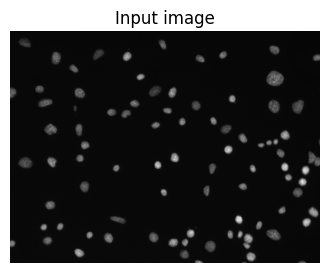

In [23]:
# Read the image
nuc = ski.io.imread(nuc_image_path)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(nuc, cmap = 'gray')
ax.set_title('Input image')
ax.set_axis_off()

Smooth the image with a Gaussian filter. The sigma of the filter determines the
level of smoothness.  This image does not have too many variations and so a
small sigma should suffice.

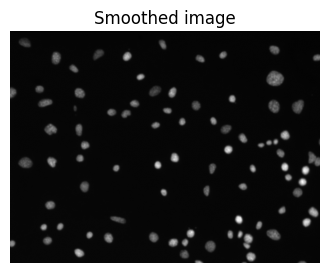

In [24]:
# Smooth the image with a Gaussian filter 
nuc_smooth = ski.filters.gaussian(nuc, sigma = nuc_gaussian_sigma)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(nuc_smooth, cmap = 'gray')
ax.set_title('Smoothed image')
ax.set_axis_off()

Binary threshold the image. Otsu thresholding is probably the better choice
here since it picks a lower threshold than the triangle method, and hence the
nuclei that are very close to one another will not be merged. However, for
illustration, let us use the triangle method so that we can separate out merged
nuclei later. 

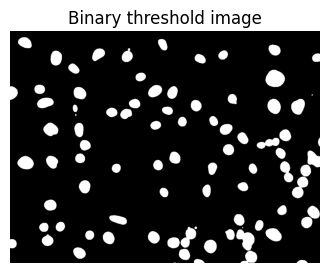

In [25]:
# Binary threshold the image
nuc_binary = nuc_smooth > ski.filters.threshold_triangle(nuc_smooth)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(nuc_binary, cmap = 'gray')
ax.set_title('Binary threshold image')
ax.set_axis_off()

Notice that there are several tiny spots that are too small to be a nuclei. We
can get rid of such tiny artifacts by erosion. Since these spots are circular
it is best to use a disk or elliptical structuring element. The radius of the
structuring element will determine the size of the nuclei that remain. 

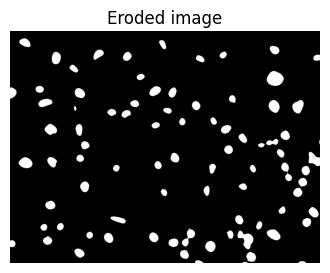

In [26]:
# remove unwanted spots by erosion
nuc_erosion_se = ski.morphology.ellipse(nuc_erosion_radius, nuc_erosion_radius)
nuc_erode = ski.morphology.binary_erosion(nuc_binary, nuc_erosion_se)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(nuc_erode, cmap = 'gray')
ax.set_title('Eroded image')
ax.set_axis_off()

We can then get the distance transform of the image, and get the inverse of it
such that the pixels at the center of each nuclei has the lowest value. 

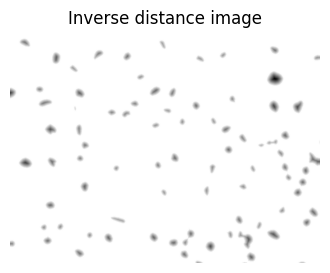

In [27]:
# get the nuclear distance and the h-minima
nuc_dist = -ndi.distance_transform_edt(nuc_erode)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(nuc_dist, cmap = 'gray')
ax.set_title('Inverse distance image')
ax.set_axis_off()

Get the seeds for watershed segmentation by getting the minima points in the
above inverse distance transform. The value of `h` in the minima determines the
number of seeds retained, i.e only seeds that a height more than specified `h`
will remain.  This can still retain seeds that are very close to one another, such
seeds can be merged with a dilation. The seeds are then labeled with a unique
value to pass on to watershed segmentation.

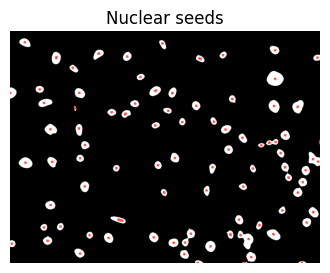

In [28]:
# Get the h-minima
nuc_seed = ski.morphology.h_minima(nuc_dist, h = nuc_h_minima)

# merge seeds that are too close to one another by dilation
nuc_seeds_se = ski.morphology.ellipse(nuc_seeds_radius, nuc_seeds_radius)
nuc_seed_big = ski.morphology.binary_dilation(nuc_seed, nuc_seeds_se)

# label the seeds with a unique ID
nuc_seed_label = ski.morphology.label(nuc_seed_big)

# label overlay for visualization
overlay_seed = ski.color.label2rgb(nuc_seed_label, nuc_erode, 
    alpha = 0.7, bg_label = 0, bg_color = None, colors = [(1, 0, 0)])

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(overlay_seed, cmap = 'gray')
ax.set_title('Nuclear seeds')
ax.set_axis_off()

Finally, do a watershed segmentation to get the final nuclear label map.
Watershed is performed on the inverse distance image with the above
seeds, and using the binary thresholded image as a mask. 

Number of seeds: 89


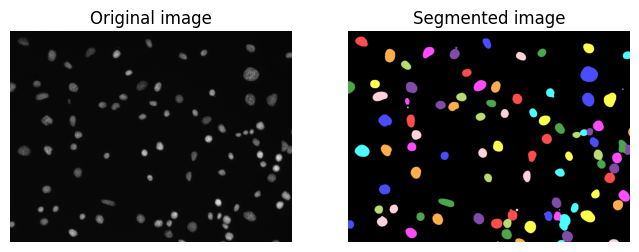

In [29]:
# Watershed segmentation
nuc_label_img = ski.segmentation.watershed(nuc_dist, 
    markers = nuc_seed_label, mask = nuc_binary)

# Overlay the segmented labels for visualization 
overlay = ski.color.label2rgb(nuc_label_img, nuc_binary, 
    alpha = 0.7, bg_color = None)

print('Number of seeds: ' + str(nuc_label_img.max()))

# Plot the images
fig, ax =  plt.subplots(1, 2, figsize = (8, 4))
ax[0].imshow(nuc, cmap = 'gray')
ax[0].set_title('Original image')
ax[1].imshow(overlay)
ax[1].set_title('Segmented image')
for a in ax:
    a.set_axis_off()

# Segmenting the cytoplasm

Segmenting the cytoplasm is mostly similar to segmenting the nuclei, with a few
minor differences. 

Define the segmentation parameters:

In [30]:
# Define the parameter
cyto_image_path = 'data/F01_202w1.TIF'
cyto_gamma = 0.1
cyto_gaussian_sigma = 3
cyto_ws_compactness = 0.01

Read in the input image:

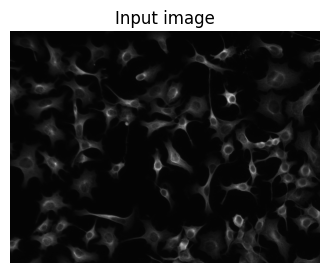

In [31]:
# Read in the image
cyto = ski.io.imread(cyto_image_path)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(cyto, cmap = 'gray')
ax.set_title('Input image')
ax.set_axis_off()

The input image is really dim, and so we can brighten it with gamma correction.
Binary thresholding without gamma correction will likely miss many regions. 

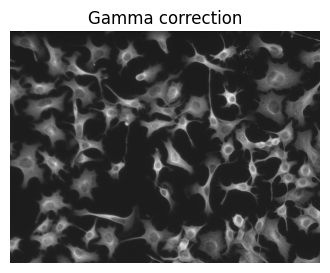

In [32]:
# Gamma correction to make the image brighter
cyto_gamma = ski.exposure.adjust_gamma(cyto, cyto_gamma)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(cyto_gamma, cmap = 'gray')
ax.set_title('Gamma correction')
ax.set_axis_off()

Gaussian smooth the image:

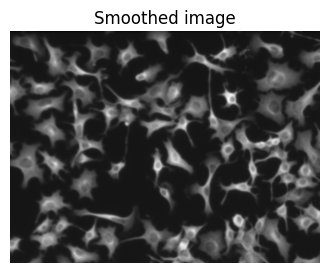

In [33]:
# Gaussian smooth the image
cyto_smooth = ski.filters.gaussian(cyto_gamma, sigma = cyto_gaussian_sigma)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(cyto_smooth, cmap = 'gray')
ax.set_title('Smoothed image')
ax.set_axis_off()

Binary threshold the image. Try to threshold the image without gamma correction
to see the how much more foreground we get with the correction.

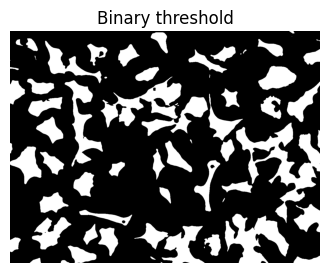

In [34]:
# Otsu threshold the image
cyto_binary = cyto_smooth > ski.filters.threshold_otsu(cyto_smooth)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(cyto_binary, cmap = 'gray')
ax.set_title('Binary threshold')
ax.set_axis_off()

We can get rid of the hols in the cytoplasm using morphological hole filling.

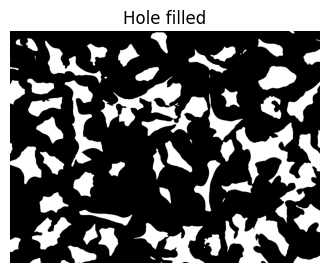

In [35]:
# Fill holes in the cytoplasm
cyto_filled = ndi.binary_fill_holes(cyto_binary)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(cyto_filled, cmap = 'gray')
ax.set_title('Hole filled')
ax.set_axis_off()

Get the distance transform and invert it:

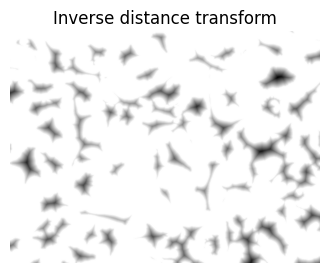

In [36]:
cyto_dist = -ndi.distance_transform_edt(cyto_filled)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(cyto_dist, cmap = 'gray')
ax.set_title('Inverse distance transform')
ax.set_axis_off()

The cytoplasm has a very irregular shape, and so taking the minima points as
seeds will not work as there will be too many of them, and the minima will not
correspond to the center of the cytoplasm. Alternatively, since each cell has
only one nuclei, we can use those as the seeds for segmenting the cytoplasm.

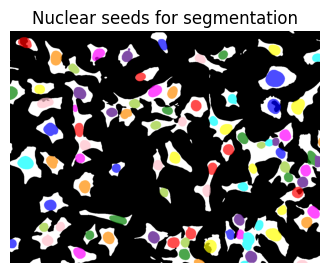

In [37]:
# Nuclear seeds over the cytoplasm for visualization
overlay_cyto_seed = ski.color.label2rgb(
    nuc_label_img, cyto_filled, alpha = 0.7, bg_color = None)

fig, ax =  plt.subplots(figsize = (4, 4))
ax.imshow(overlay_cyto_seed, cmap = 'gray')
ax.set_title('Nuclear seeds for segmentation')
ax.set_axis_off()

Finally, watershed segment cytoplasm with the nuclear segmentation as the
seeds:

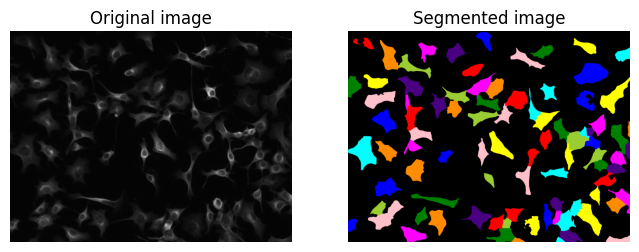

In [38]:
# watershed segmentation
cyto_label_img = ski.segmentation.watershed(cyto_dist, 
    mask = cyto_filled, markers = nuc_label_img, compactness = cyto_ws_compactness)

# colored label map for visualization
cyto_overlay = ski.color.label2rgb(cyto_label_img)


# Plot the images
fig, ax =  plt.subplots(1, 2, figsize = (8, 4))
ax[0].imshow(cyto, cmap = 'gray')
ax[0].set_title('Original image')
ax[1].imshow(cyto_overlay, cmap = 'gray')
ax[1].set_title('Segmented image')
for a in ax:
    a.set_axis_off()

# Feature extraction
Now that we have a cell mask, we can use it extract the desired features from
the original image. The x and y pixel spacing between each pixel are 0.31um for
these images, supplying that to the functions gives us the accurate cell size
(as opposed to the cell size in pixel).  The features can then be used for
plotting or any other downstream applications. 

Text(0, 0.5, 'Cytoplasm intensity')

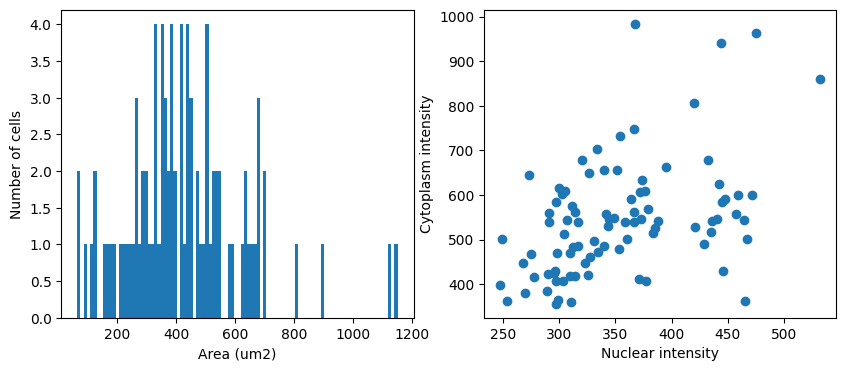

In [39]:
# the properties
cyto_features = ski.measure.regionprops(cyto_label_img, 
    intensity_image = cyto, spacing = (0.31, 0.31))
nuc_features = ski.measure.regionprops(cyto_label_img, 
    intensity_image = nuc, spacing = (0.31, 0.31))

cyto_area = []
nuc_intensity = []
cyto_intensity = []

for c, n in zip(cyto_features, nuc_features):
    cyto_area.append(c.area)
    cyto_intensity.append(c.intensity_mean)
    nuc_intensity.append(n.intensity_mean)

fig, ax = plt.subplots(1, 2, figsize = (10, 4))
ax[0].hist(cyto_area, bins = 100)
ax[0].set_xlabel('Area (um2)')
ax[0].set_ylabel('Number of cells')
ax[1].scatter(nuc_intensity, cyto_intensity)
ax[1].set_xlabel('Nuclear intensity')
ax[1].set_ylabel('Cytoplasm intensity')